In [2]:
import cv2
import numpy as np
import json
import matplotlib.pyplot as plt
import os

In [3]:
# === CONFIGURATION ===
input_path = "buildingfootprint_trial.png"
output_geojson_path = "building_contours.geojson"

In [4]:
# === STEP 1: Load grayscale image ===
image = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)
if image is None:
    raise FileNotFoundError(f"Image not found at {input_path}")

# FILTERING

## METHOD 1 (INSUFFICIENT)

In [12]:
def detect_and_draw_contours(binary_image, min_area=100, max_area=10000, original_image=None):
    """
    Detect and draw contours on white elements in a binary image, filtering by area.
    
    Args:
        binary_image: Binary image with white elements to detect
        min_area: Minimum contour area to include (default: 100)
        max_area: Maximum contour area to include (default: 10000)
        original_image: Image to draw contours on (if None, will create a color version of binary_image)
    
    Returns:
        Tuple of (image with contours, list of filtered contours)
    """
    # Make a copy of the binary image
    binary = binary_image.copy()
    
    # If original image not provided, convert binary to BGR
    if original_image is None:
        draw_image = cv2.cvtColor(binary, cv2.COLOR_GRAY2BGR)
    else:
        draw_image = original_image.copy()
    
    # Find contours
    contours, hierarchy = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Filter contours by area
    filtered_contours = []
    for contour in contours:
        area = cv2.contourArea(contour)
        if min_area <= area <= max_area:
            filtered_contours.append(contour)
            # Draw contour
            cv2.drawContours(draw_image, [contour], -1, (0, 0, 255), 2)
            
            # Optionally draw area text
            M = cv2.moments(contour)
            if M["m00"] != 0:
                cx = int(M["m10"] / M["m00"])
                cy = int(M["m01"] / M["m00"])
                cv2.putText(draw_image, f"Area: {int(area)}", (cx, cy), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
    
    print(f"Found {len(filtered_contours)} contours within area range [{min_area}, {max_area}]")
    return draw_image, filtered_contours

In [13]:

result_img, contours = detect_and_draw_contours(
    image, 
    min_area=500,  # Adjust minimum area as needed
    max_area=5000  # Adjust maximum area as needed
)

# Display the result
cv2.imshow('Filtered Contours', result_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

# If you need statistics about the contours
for i, cnt in enumerate(contours):
    area = cv2.contourArea(cnt)
    print(f"Contour {i+1}: Area = {area}")

Found 244 contours within area range [500, 5000]
Contour 1: Area = 902.5
Contour 2: Area = 774.5
Contour 3: Area = 1467.5
Contour 4: Area = 520.5
Contour 5: Area = 1146.5
Contour 6: Area = 1222.0
Contour 7: Area = 861.0
Contour 8: Area = 2116.0
Contour 9: Area = 3909.5
Contour 10: Area = 1253.0
Contour 11: Area = 2782.5
Contour 12: Area = 3576.0
Contour 13: Area = 1098.5
Contour 14: Area = 1822.5
Contour 15: Area = 1274.5
Contour 16: Area = 4001.0
Contour 17: Area = 504.5
Contour 18: Area = 2525.5
Contour 19: Area = 1129.0
Contour 20: Area = 2698.5
Contour 21: Area = 3422.0
Contour 22: Area = 581.0
Contour 23: Area = 1390.5
Contour 24: Area = 639.0
Contour 25: Area = 1290.5
Contour 26: Area = 592.0
Contour 27: Area = 1204.5
Contour 28: Area = 1609.0
Contour 29: Area = 979.0
Contour 30: Area = 1033.0
Contour 31: Area = 3371.5
Contour 32: Area = 638.0
Contour 33: Area = 1362.5
Contour 34: Area = 4152.5
Contour 35: Area = 617.0
Contour 36: Area = 1445.0
Contour 37: Area = 1392.5
Contour 3

## METHOD 2 (GOOD)

In [ ]:
def detect_and_filter_contours(binary_image, min_area=100, max_area=10000, 
                              max_aspect_ratio=5.0, min_circularity=0.3, 
                              original_image=None):

    # Make a copy of the binary image
    binary = binary_image.copy()
    
    # If original image not provided, convert binary to BGR
    if original_image is None:
        draw_image = cv2.cvtColor(binary, cv2.COLOR_GRAY2BGR)
    else:
        draw_image = original_image.copy()
    
    # Find contours
    contours, hierarchy = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Filter contours by area and shape
    filtered_contours = []
    for contour in contours:
        area = cv2.contourArea(contour)
        
        # Skip if outside area range
        if not (min_area <= area <= max_area):
            continue
        
        # Calculate shape descriptors
        perimeter = cv2.arcLength(contour, True)
        
        # Circularity (4π*area/perimeter²) - 1.0 is a perfect circle
        circularity = 4 * np.pi * area / (perimeter * perimeter) if perimeter > 0 else 0
        
        # Get bounding rectangle and calculate aspect ratio
        x, y, w, h = cv2.boundingRect(contour)
        aspect_ratio = max(w/h if h > 0 else float('inf'), h/w if w > 0 else float('inf'))
        
        # Skip if too elongated or not circular enough
        if aspect_ratio > max_aspect_ratio or circularity < min_circularity:
            # Draw rejected contours in red (optional)
            cv2.drawContours(draw_image, [contour], -1, (0, 0, 255), 1)
            continue
        
        # Add to filtered contours and draw in green
        filtered_contours.append(contour)
        cv2.drawContours(draw_image, [contour], -1, (0, 255, 0), 2)
        
        # Draw shape measurements (optional)
        M = cv2.moments(contour)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            cv2.putText(draw_image, f"AR:{aspect_ratio:.2f}", (cx, cy-15), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
            cv2.putText(draw_image, f"Circ:{circularity:.2f}", (cx, cy+15), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
    
    print(f"Found {len(filtered_contours)} contours matching all criteria")
    return draw_image, filtered_contours

In [9]:
# Filter contours by area and shape
result_img, good_contours = detect_and_filter_contours(
    image, 
    min_area=500,
    max_area=10000,
    max_aspect_ratio=4.0,  # Lower = less elongated objects allowed
    min_circularity=0.2    # Higher = more circular objects required
)

cv2.imshow('Filtered Contours', result_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

Found 219 contours matching all criteria


## METHOD 3 (TERRIBLE)

Detected 1091 raw contours
Filtered to 121 contours with area between 250 and 500 px


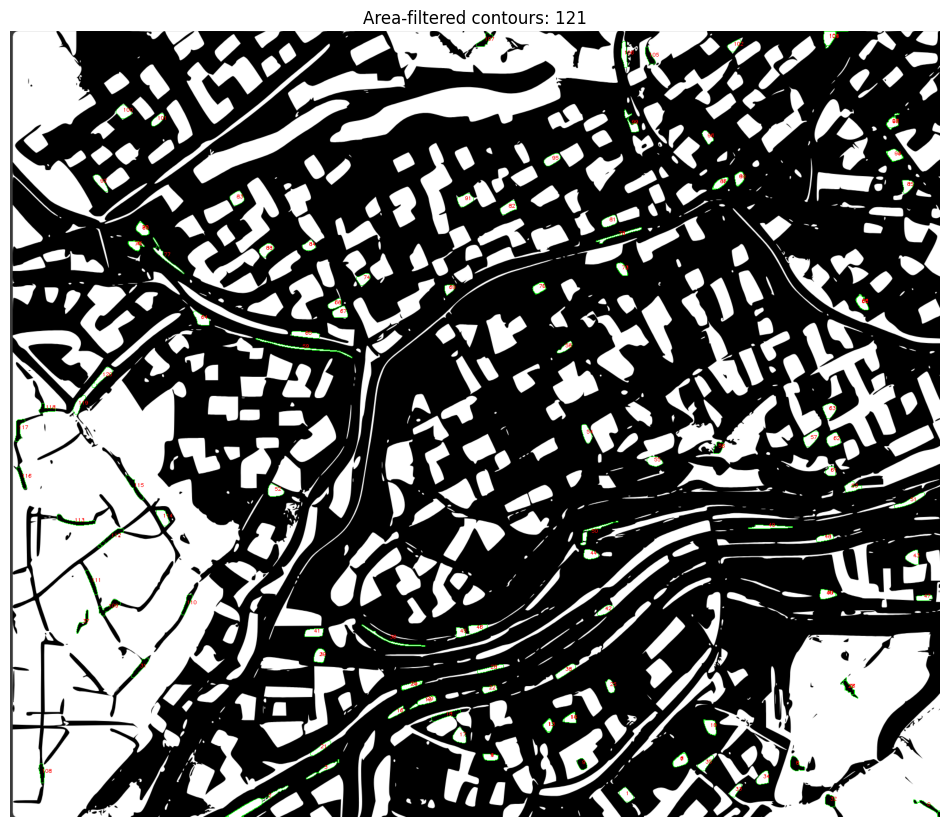

In [9]:
# === STEP 2: Canny Edge Detection ===
edges = cv2.Canny(image, 50, 150)  # Try (30, 120) or (60, 180) for different sensitivity

# === STEP 3: Morphological Closing ===
kernel = np.ones((3, 3), np.uint8)
closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=2)

# === STEP 4: Find all contours (internal + external) ===
contours, _ = cv2.findContours(closed, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
print(f"Detected {len(contours)} raw contours")

# === STEP 5: Filter small contours by area ===
# ...after finding contours...

min_area = 250
max_area = 500  # Adjust as needed

filtered_contours = [cnt for cnt in contours if min_area <= cv2.contourArea(cnt) <= max_area]
print(f"Filtered to {len(filtered_contours)} contours with area between {min_area} and {max_area} px")

# === Preview plot of area-filtered contours ===
preview = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
for i, cnt in enumerate(filtered_contours):
    cv2.drawContours(preview, [cnt], -1, (0, 255, 0), 1)
    M = cv2.moments(cnt)
    if M["m00"] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        cv2.putText(preview, str(i), (cx, cy), cv2.FONT_HERSHEY_SIMPLEX, 0.3, (0, 0, 255), 1)

plt.figure(figsize=(12, 12))
plt.imshow(cv2.cvtColor(preview, cv2.COLOR_BGR2RGB))
plt.title(f"Area-filtered contours: {len(filtered_contours)}")
plt.axis("off")
plt.show()

In [5]:
# === STEP X: Polygonal Approximation to straighten contours ===
epsilon_ratio = 0.01
cleaned_contours = []
for cnt in filtered_contours:
    epsilon = epsilon_ratio * cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, epsilon, True)
    cleaned_contours.append(approx)

In [6]:
def contour_centroid(cnt):
    M = cv2.moments(cnt)
    if M["m00"] == 0:
        return None
    cx = int(M["m10"] / M["m00"])
    cy = int(M["m01"] / M["m00"])
    return np.array([cx, cy])

def max_min_dist_to_centroid(cnt, centroid):
    dists = np.linalg.norm(cnt.squeeze() - centroid, axis=1)
    return dists.max(), dists.min()

MAX_DIST = 120
MIN_DIST = 10

final_contours = []
for cnt in cleaned_contours:
    centroid = contour_centroid(cnt)
    if centroid is None:
        continue
    max_dist, min_dist = max_min_dist_to_centroid(cnt, centroid)
    if max_dist > MAX_DIST or min_dist < MIN_DIST:
        continue
    final_contours.append(cnt)

print(f"Contours after centroid distance filtering: {len(final_contours)}")

Contours after centroid distance filtering: 6


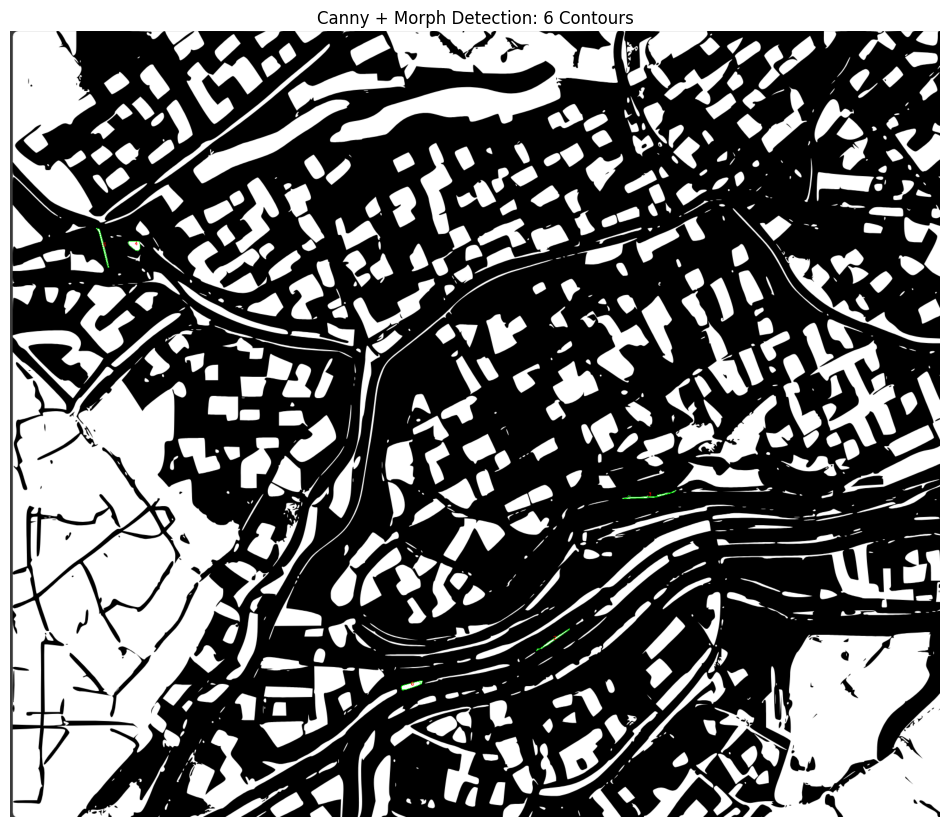

In [7]:
# === STEP 6: Preview — draw contours and label IDs ===
preview = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
for i, cnt in enumerate(final_contours):
    cv2.drawContours(preview, [cnt], -1, (0, 255, 0), 1)
    M = cv2.moments(cnt)
    if M["m00"] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        cv2.putText(preview, str(i), (cx, cy), cv2.FONT_HERSHEY_SIMPLEX, 0.3, (0, 0, 255), 1)
        
plt.figure(figsize=(12, 12))
plt.imshow(cv2.cvtColor(preview, cv2.COLOR_BGR2RGB))
plt.title(f"Canny + Morph Detection: {len(final_contours)} Contours")
plt.axis("off")
plt.show()

Detected 1091 raw contours
Filtered to 671 contours > 200 px
Contours after centroid distance filtering: 383


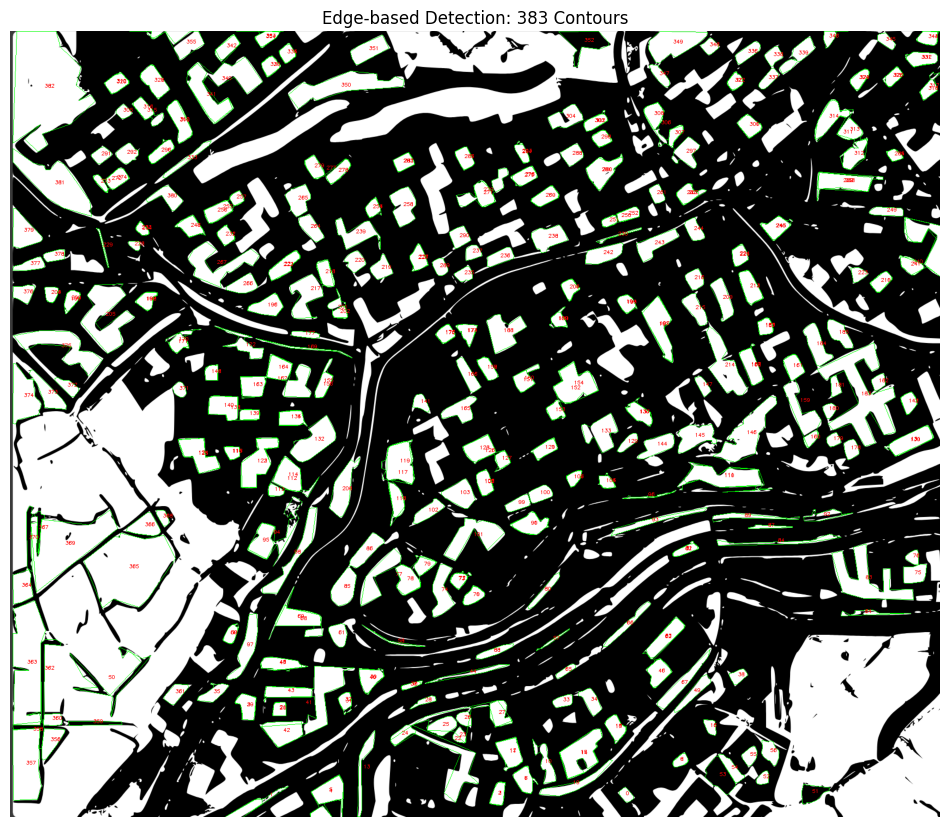

In [8]:
# === Improved: Edge Detection + Morph Closing + Centroid Distance Filtering ===

# 1. Apply Canny Edge Detection (tune thresholds if needed)
edges = cv2.Canny(image, 50, 150)

# 2. Apply Morphological Closing to connect outlines
kernel = np.ones((3, 3), np.uint8)
closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=2)

# 3. Find contours (inner + outer)
contours, _ = cv2.findContours(closed, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
print(f"Detected {len(contours)} raw contours")

# 4. Filter by area to ignore tiny specks
min_area = 200
filtered_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_area]
print(f"Filtered to {len(filtered_contours)} contours > {min_area} px")

# 5. Polygonal Approximation
epsilon_ratio = 0.01
cleaned_contours = []
for cnt in filtered_contours:
    epsilon = epsilon_ratio * cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, epsilon, True)
    cleaned_contours.append(approx)

# 6. Centroid Distance Filtering
def contour_centroid(cnt):
    M = cv2.moments(cnt)
    if M["m00"] == 0:
        return None
    cx = int(M["m10"] / M["m00"])
    cy = int(M["m01"] / M["m00"])
    return np.array([cx, cy])

def max_min_dist_to_centroid(cnt, centroid):
    dists = np.linalg.norm(cnt.squeeze() - centroid, axis=1)
    return dists.max(), dists.min()

MAX_DIST = 120
MIN_DIST = 10

final_contours = []
for cnt in cleaned_contours:
    centroid = contour_centroid(cnt)
    if centroid is None:
        continue
    max_dist, min_dist = max_min_dist_to_centroid(cnt, centroid)
    if max_dist > MAX_DIST or min_dist < MIN_DIST:
        continue
    final_contours.append(cnt)

print(f"Contours after centroid distance filtering: {len(final_contours)}")

# 7. Draw + label preview
preview = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
for i, cnt in enumerate(final_contours):
    cv2.drawContours(preview, [cnt], -1, (0, 255, 0), 1)
    M = cv2.moments(cnt)
    if M["m00"] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        cv2.putText(preview, str(i), (cx, cy), cv2.FONT_HERSHEY_SIMPLEX, 0.3, (0, 0, 255), 1)

plt.figure(figsize=(12, 12))
plt.imshow(cv2.cvtColor(preview, cv2.COLOR_BGR2RGB))
plt.title(f"Edge-based Detection: {len(final_contours)} Contours")
plt.axis("off")
plt.show()

In [76]:
# === STEP 7: Export contours to GeoJSON ===
features = []
for cnt in final_contours:  # <-- use final_contours here!
    coords = cnt.squeeze().tolist()
    if not coords or isinstance(coords[0], int) or len(coords) < 3:
        continue
    if coords[0] != coords[-1]:  # Ensure closed polygon
        coords.append(coords[0])
    features.append({
        "type": "Feature",
        "geometry": {
            "type": "Polygon",
            "coordinates": [coords]
        },
        "properties": {}
    })

geojson = {
    "type": "FeatureCollection",
    "features": features
}

with open(output_geojson_path, "w") as f:
    json.dump(geojson, f, indent=2)

print(f"✅ GeoJSON exported: {output_geojson_path}")

✅ GeoJSON exported: building_contours.geojson


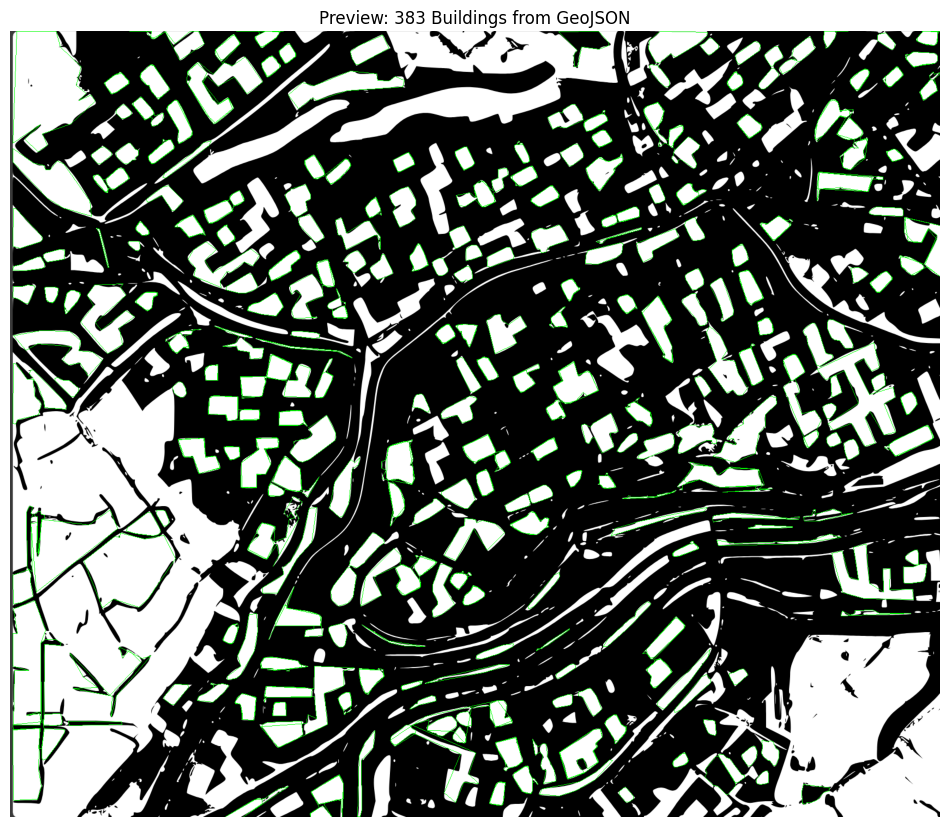

In [77]:
# === Load image again for overlay ===
background = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)
background_rgb = cv2.cvtColor(background, cv2.COLOR_GRAY2RGB)

# === Load GeoJSON ===
with open(output_geojson_path, "r") as f:
    data = json.load(f)

# === Draw polygons from GeoJSON ===
for feature in data["features"]:
    coords = np.array(feature["geometry"]["coordinates"][0], dtype=np.int32)
    cv2.polylines(background_rgb, [coords], isClosed=True, color=(0, 255, 0), thickness=1)

# === Show result ===
plt.figure(figsize=(12, 12))
plt.imshow(background_rgb)
plt.title(f"Preview: {len(data['features'])} Buildings from GeoJSON")
plt.axis("off")
plt.show()
